# Pachete necesare pentru folosirea acestui Notebook

Vom folosi [scipy](https://scipy.org/), [numpy](https://numpy.org/) si [matplotlib](https://matplotlib.org/).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import datasets, ndimage
from scipy.fft import dctn, idctn

# Imaginea cu care lucram

Vom folosi o imagine din setul de date oferit implicit de catre scipy.

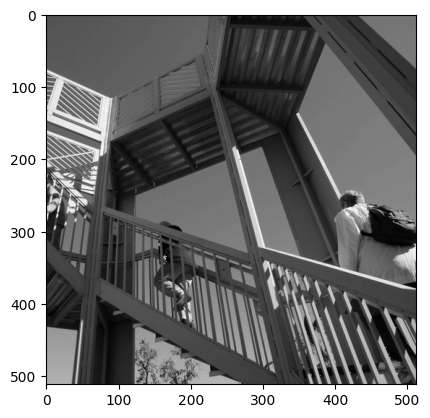

In [2]:
X = datasets.ascent()
plt.imshow(X, cmap=plt.cm.gray)
plt.show()

# Transformata DCT a unei imagini

Transformata DCT se extinde la mai multe dimensiuni similar cu transformata DFT. Pentru un semnal bidimensional, precum o imagine, DCT-II devine:

$$
Y_{m_1,m_2} = \sum_{n_1=0}^{N_1-1}
              \sum_{n_2=0}^{N_2-1}
              x_{n_1,n_2}
              \cos\left[\frac{\pi}{N_1}m_1
                \left(n_1 + \frac12\right)\right]
              \cos\left[\frac{\pi}{N_2}m_2\left(n_2 + \frac12\right)\right]
$$

* unde $n_1$ si $n_2$ sunt pozitiile pixelilor pe orizontala, respectiv, pe verticala
* bin-urile rezultate corespund positiilor pixelilor
* spectrul este in continuare simetric si par
* proprietatile transformatei DCT-II sunt respectate si in cazul celei 2D

In Python avem rutina `scipy.fft.dct` pentru 1D si `scipy.fft.dctn` pentru generalizarea la semnale $n$-dimensionale. Dimensiunea este determinata automat dupa forma semnalului; tipul DCT poate fi specificat prin atributul `type` (implicit II).

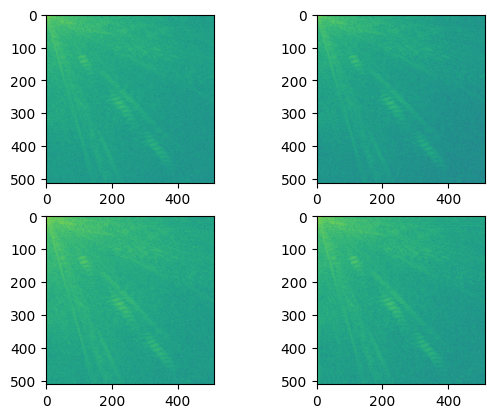

In [3]:
Y1 = dctn(X, type=1)
Y2 = dctn(X, type=2)
Y3 = dctn(X, type=3)
Y4 = dctn(X, type=4)
freq_db_1 = 20*np.log10(abs(Y1))
freq_db_2 = 20*np.log10(abs(Y2))
freq_db_3 = 20*np.log10(abs(Y3))
freq_db_4 = 20*np.log10(abs(Y4))

plt.subplot(221).imshow(freq_db_1)
plt.subplot(222).imshow(freq_db_2)
plt.subplot(223).imshow(freq_db_3)
plt.subplot(224).imshow(freq_db_4)
plt.show()

# Compactarea energiei. Compresie.

Putem profita de proprietatea compresiei energiei prin anularea frecventelor DCT incepand cu *bin*-ul `k` dupa care aplicam transformata DCT inversa (similar cu tema anterioara):

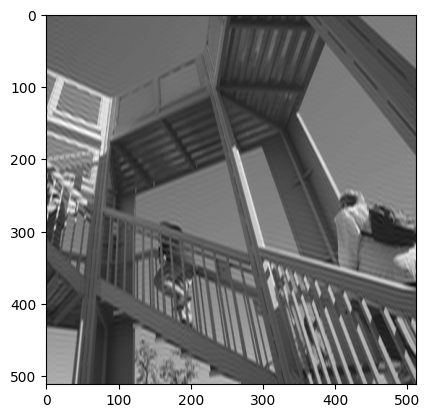

In [4]:
k = 120

Y_ziped = Y2.copy()
Y_ziped[k:] = 0
X_ziped = idctn(Y_ziped)

plt.imshow(X_ziped, cmap=plt.cm.gray)
plt.show()

# JPEG

Algoritmul de compresie JPEG are patru etape:

1. transformarea imaginii din pixeli RGB in Y'CbCr
2. aplicarea 2D-DCT pe blocuri disincte de 8x8 pixeli din imagine
3. cuantizarea in frecventa cu $Q$ dat de standardul JPEG
4. compresia rezultatului cu coduri Huffman

Unde matricea JPEG de cuantizare $Q$ este:
$$
Q =
\begin{bmatrix}
16 & 11 & 10 & 16 & 24 & 40 & 51 & 61 & \\
12 & 12 & 14 & 19 & 26 & 28 & 60 & 55 & \\
14 & 13 & 16 & 24 & 40 & 57 & 69 & 56 & \\
14 & 17 & 22 & 29 & 51 & 87 & 80 & 62 & \\
18 & 22 & 37 & 56 & 68 & 109 & 103 & 77 & \\
24 & 35 & 55 & 64 & 81 & 104 & 113 & 92 & \\
49 & 64 & 78 & 87 & 103 & 121 & 120 & 101\\
72 & 92 & 95 & 98 & 112 & 100 & 103 & 99\\
\end{bmatrix}
$$

Imaginea noastra de test este monocroma, deci nu necesita pasul 1, dar putem efectua o operatie de *down-sampling* in preprocesare precum am prezentat la curs.

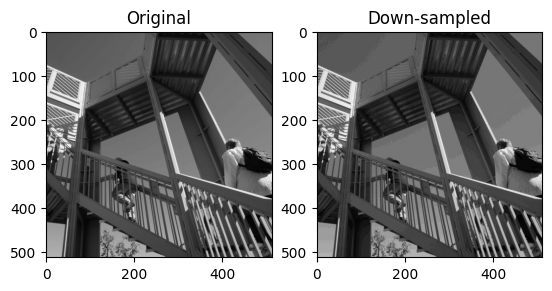

In [5]:
Q_down = 10

X_jpeg = X.copy()
X_jpeg = Q_down*np.round(X_jpeg/Q_down)

plt.subplot(121).imshow(X, cmap=plt.cm.gray)
plt.title('Original')
plt.subplot(122).imshow(X_jpeg, cmap=plt.cm.gray)
plt.title('Down-sampled')
plt.show()

Pentru fiecare bloc de $8\times 8$ aplica DCT si cuantizare.

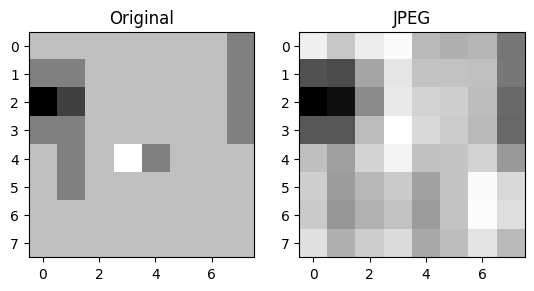

Componente in frecventa:64
Componente in frecventa dupa cuantizare: 14


In [6]:
Q_jpeg = [[16, 11, 10, 16, 24, 40, 51, 61],
          [12, 12, 14, 19, 26, 28, 60, 55],
          [14, 13, 16, 24, 40, 57, 69, 56],
          [14, 17, 22, 29, 51, 87, 80, 62],
          [18, 22, 37, 56, 68, 109, 103, 77],
          [24, 35, 55, 64, 81, 104, 113, 92],
          [49, 64, 78, 87, 103, 121, 120, 101],
          [72, 92, 95, 98, 112, 100, 103, 99]]

# Encoding
x = X[:8, :8]
y = dctn(x)
y_jpeg = Q_jpeg*np.round(y/Q_jpeg)

# Decoding
x_jpeg = idctn(y_jpeg)

# Results
y_nnz = np.count_nonzero(y)
y_jpeg_nnz = np.count_nonzero(y_jpeg)

plt.subplot(121).imshow(x, cmap=plt.cm.gray)
plt.title('Original')
plt.subplot(122).imshow(x_jpeg, cmap=plt.cm.gray)
plt.title('JPEG')
plt.show()

print('Componente in frecventa:' + str(y_nnz) + 
      '\nComponente in frecventa dupa cuantizare: ' + str(y_jpeg_nnz))

# Sarcini

1. [6p] Completati algoritmul JPEG incluzand toate blocurile din imagine.

2. [4p] Extindeti la imagini color (incluzand transformarea din RGB in Y'CbCr).

3. [6p] Extindeti algoritmul pentru compresia imaginii pana la un prag MSE impus de utilizator.

4. [4p] Extindeti algoritmul pentru compresie video. Demonstrati pe un clip scurt din care luati fiecare cadru si il tratati ca pe o imagine.

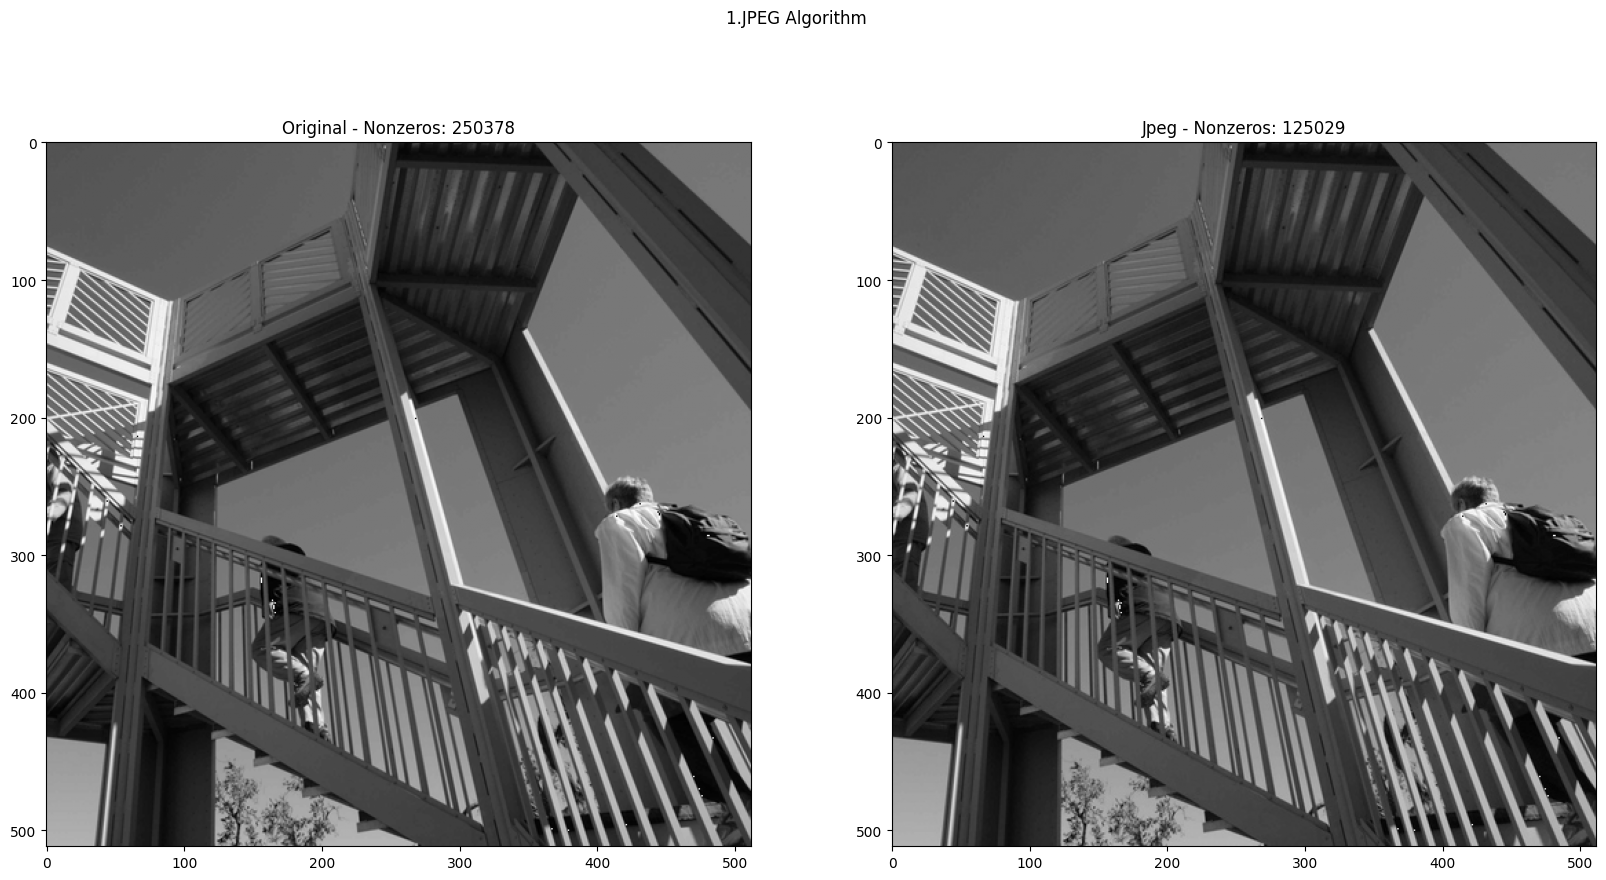

In [7]:
# 1.
def jpeg(X, plot = False, qf = 1):
    h, w = X.shape

    h = (h//8) * 8
    w = (w//8) * 8

    x_jpeg = np.zeros((h,w))

    count_nonzeros = 0
    jpeg_count_nonzeros = 0

    Q = np.array(Q_jpeg)
    
    for i in range(h//8):
        for j in range(w//8):
            l_start = i * 8
            l_end = l_start + 8
            
            c_start = j * 8
            c_end = c_start + 8
            
            # print(l_start,l_end)
            # print(c_start,c_end)
            
            x = X[l_start:l_end, c_start:c_end]
            
            y = dctn(x)
            count_nonzeros += np.count_nonzero(y)
            
            q = Q * qf
            y_jpeg = q *np.round(y/q)
            jpeg_count_nonzeros += np.count_nonzero(y_jpeg)
                    
            x_jpeg[l_start:l_end, c_start:c_end] = idctn(y_jpeg)

    if plot:
        fig, axs = plt.subplots(1,2, figsize = (20,10))
        fig.suptitle('1.JPEG Algorithm')

        axs[0].imshow(X, cmap=plt.cm.gray)
        axs[0].set_title(f'Original - Nonzeros: {count_nonzeros}')

        axs[1].imshow(x_jpeg, cmap=plt.cm.gray)
        axs[1].set_title(f'Jpeg - Nonzeros: {jpeg_count_nonzeros}')

        plt.savefig('1.pdf')
        plt.show()
    
    return x_jpeg

output = jpeg(X, True)
plt.imsave('Poza.jpeg', output, cmap='gray')


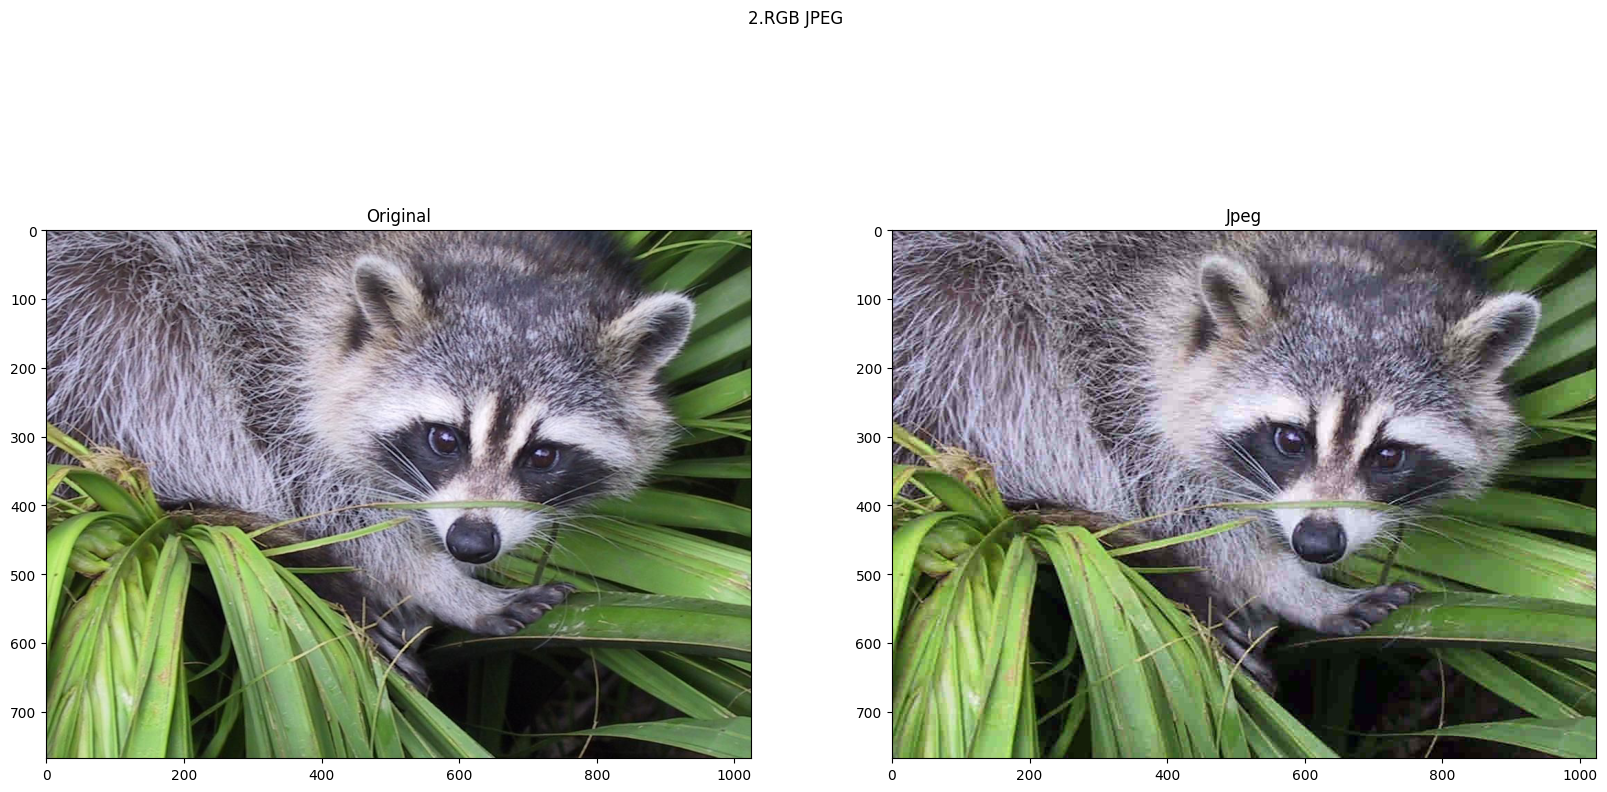

In [8]:
# 2.

def to_ycbcr(v):
    R = v[:,:,0]
    G = v[:,:,1]
    B = v[:,:,2]
    
    Y  = 0.299 * R + 0.587 * G + 0.114 * B
    Cb = 128.0 + (-0.168736 * R -  0.331264 * G + 0.5 * B) 
    Cr = 128.0 + (0.5 * R -  0.418688 * G -  0.081312 * B) 
    
    return np.stack((Y, Cb, Cr), axis=2)

def to_rgb(v):
    Y = v[:,:,0]
    Cb = v[:,:,1] - 128
    Cr = v[:,:,2] - 128
    
    R = Y + 1.402 * Cr
    G = Y - 0.344136 * Cb - 0.714136 * Cr
    B = Y + 1.772 * Cb
    
    R = np.clip(R, 0, 255)
    G = np.clip(G, 0, 255)
    B = np.clip(B, 0, 255)
    
    return np.stack((R, G, B), axis=2).astype(np.uint8)

def jpeg_rgb(X_color, plot = False, qf = 1):
    
    y = to_ycbcr(X_color)
    
    y[:,:,0] = jpeg(y[:,:,0], False, qf)
    y[:,:,1] = jpeg(y[:,:,1], False, qf)
    y[:,:,2] = jpeg(y[:,:,2], False, qf)
    
    x = to_rgb(y)

    if plot:
        fig, axs = plt.subplots(1,2, figsize = (20,10))
        fig.suptitle('2.RGB JPEG')

        axs[0].imshow(X_color)
        axs[0].set_title(f'Original')

        axs[1].imshow(x)
        axs[1].set_title(f'Jpeg')

        plt.savefig('2.pdf')
        plt.show()
    
    
    return x

X_color = datasets.face()
output = jpeg_rgb(X_color,True, 100)
plt.imsave('Poza_color.jpeg', output)


2. MSE: 142.79366465671376, quantization factor: 127.505
3. MSE: 86.48071211354485, quantization factor: 63.7575
4. MSE: 49.88650211477132, quantization factor: 31.88375
5. MSE: 27.25021835493645, quantization factor: 15.946875
6. MSE: 12.362156559589144, quantization factor: 7.9784375
7. MSE: 20.069800336231804, quantization factor: 11.96265625
8. MSE: 16.182674007540765, quantization factor: 9.970546875
9. MSE: 14.233473888042935, quantization factor: 8.974492187500001
10. MSE: 15.194628061847999, quantization factor: 9.47251953125
11. MSE: 14.711497544788063, quantization factor: 9.223505859375
12. MSE: 14.953293241602138, quantization factor: 9.348012695312502
13. MSE: 15.073265152537349, quantization factor: 9.410266113281251
14. MSE: 15.012942915657765, quantization factor: 9.379139404296875
15. MSE: 14.98204399914217, quantization factor: 9.363576049804688
16. MSE: 14.996863773789654, quantization factor: 9.371357727050782
17. MSE: 15.004762474560394, quantization factor: 9.3752

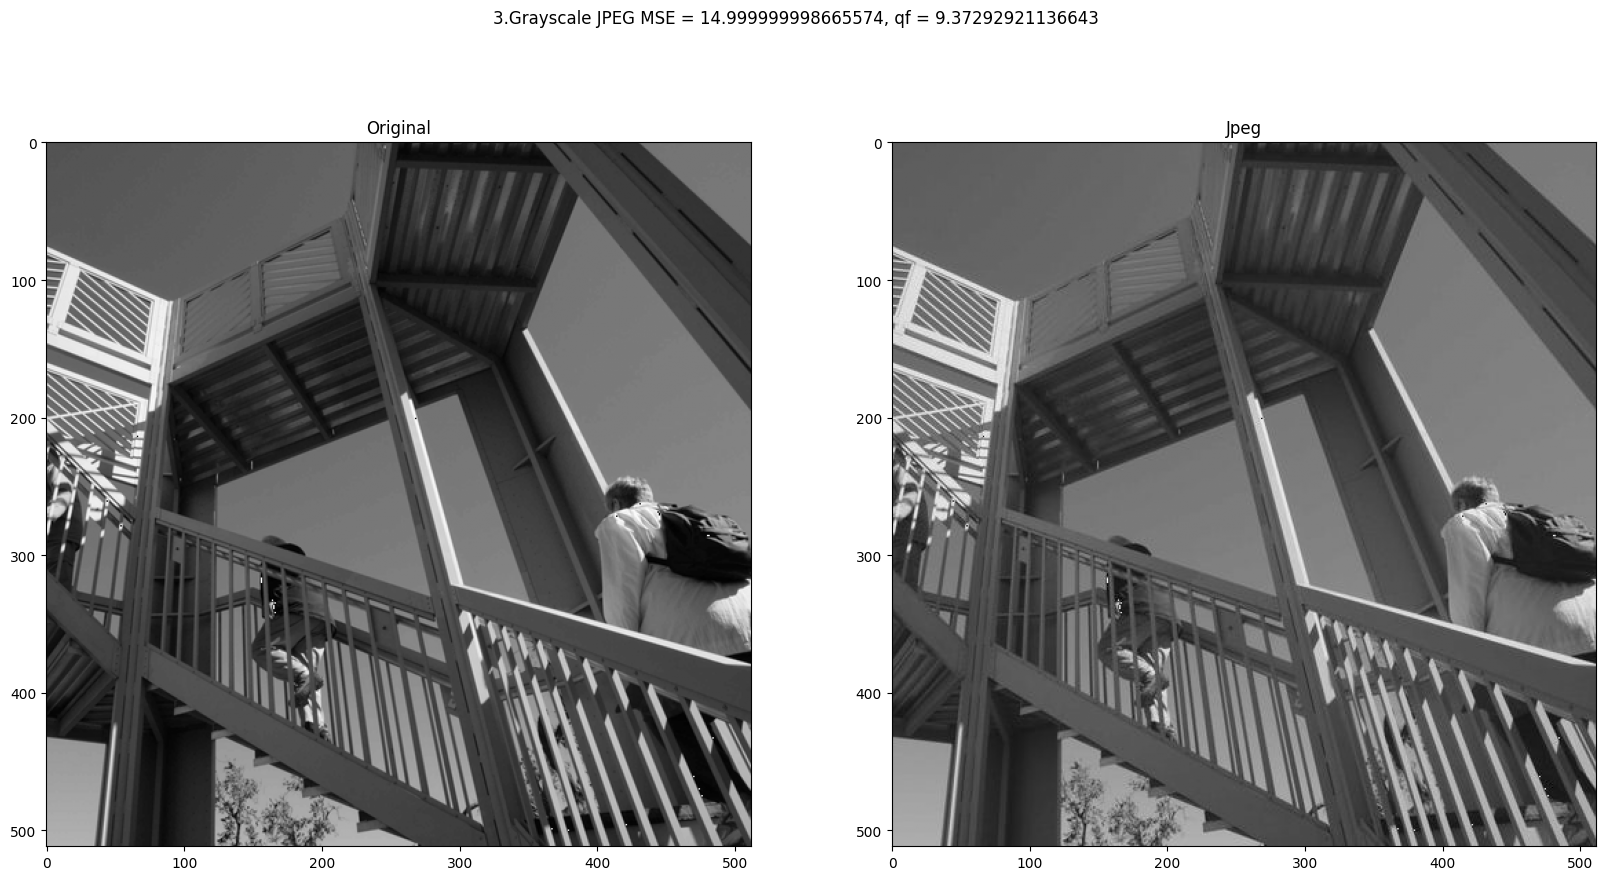

2. MSE: 57.47430335150825, quantization factor: 127.505
3. MSE: 40.01359939575195, quantization factor: 63.7575
4. MSE: 21.86566670735677, quantization factor: 31.88375
5. MSE: 12.510790506998697, quantization factor: 15.946875
6. MSE: 16.809055752224392, quantization factor: 23.9153125
7. MSE: 14.702836354573568, quantization factor: 19.93109375
8. MSE: 15.714575873480902, quantization factor: 21.923203125
9. MSE: 15.117482503255209, quantization factor: 20.9271484375
10. MSE: 14.869984520806208, quantization factor: 20.42912109375
11. MSE: 14.993614620632597, quantization factor: 20.678134765625
12. MSE: 15.052814059787325, quantization factor: 20.8026416015625
13. MSE: 15.024085998535156, quantization factor: 20.74038818359375
14. MSE: 15.006357828776041, quantization factor: 20.709261474609377
15. MSE: 15.000635782877604, quantization factor: 20.69369812011719
16. MSE: 14.992670271131727, quantization factor: 20.685916442871097
17. MSE: 14.997689988878038, quantization factor: 20.6

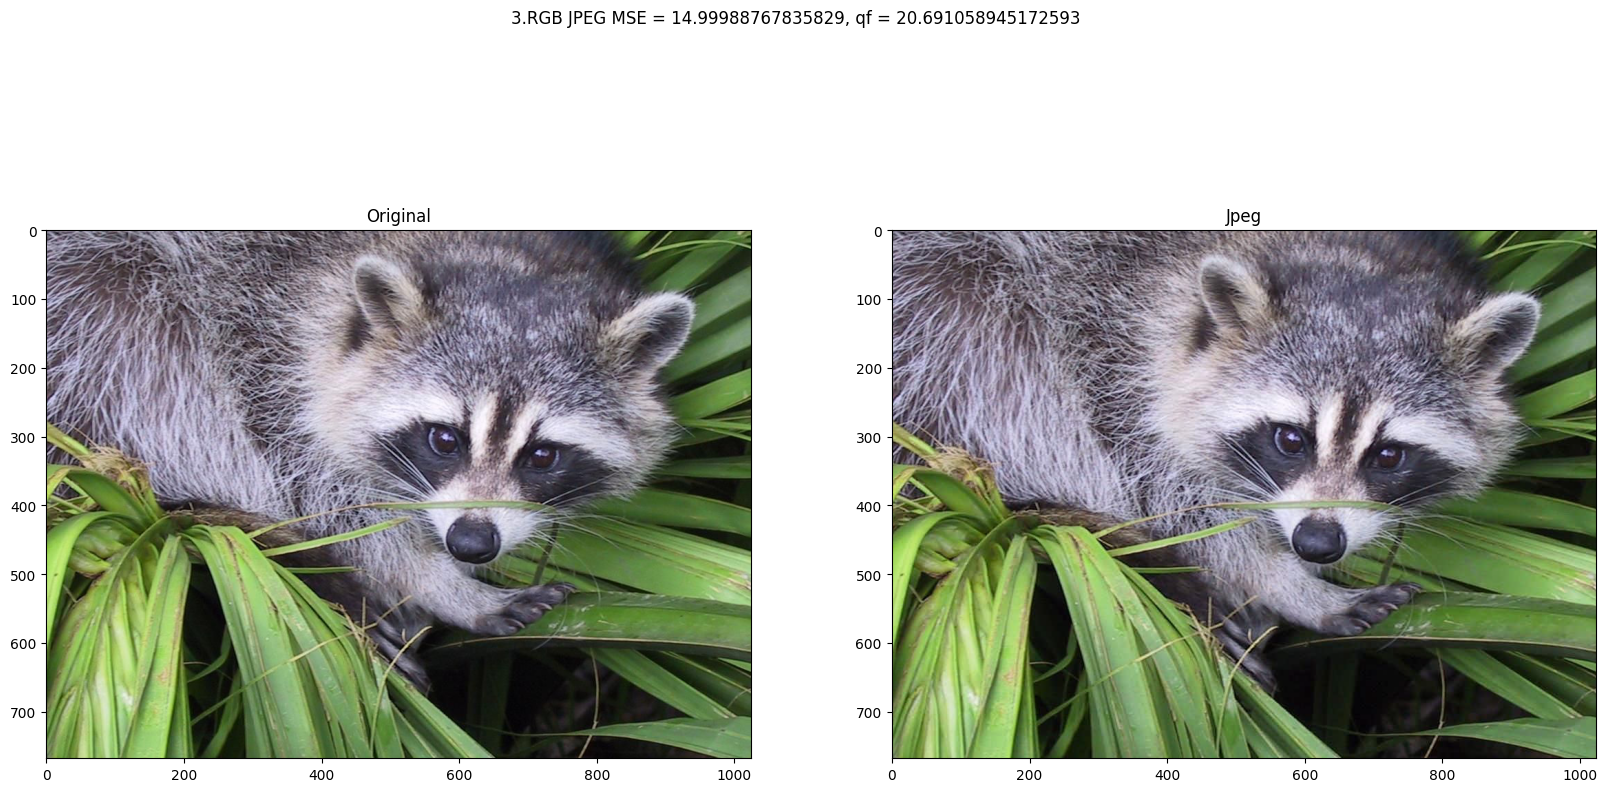

In [ ]:
# 3.
def mse_jpeg(X, th, plot = False, rgb = False):
    max_it = 50
    l_qf = 0.01
    r_qf = 255
    cnt = 0
    
    while np.round(l_qf,8) < np.round(r_qf,8) and cnt < max_it:
        qf = (l_qf + r_qf) / 2
        cnt += 1
        
        if rgb:
            y = jpeg_rgb(X, False, qf)
            MSE = (np.mean((y[:,:,0]-X[:,:,0])**2) + np.mean((y[:,:,1]-X[:,:,1])**2) + np.mean((y[:,:,2]-X[:,:,2])**2)) / 3
        else:
            y = jpeg(X, False, qf)
            MSE = np.mean((y-X) ** 2)
            
        print(f"{cnt}. MSE: {MSE}, quantization factor: {qf}")
        
        if MSE < th:
            l_qf = qf 
        else:
            r_qf = qf  
    
    if rgb:
        y = jpeg_rgb(X, False, l_qf)
        best_mse = (np.mean((y[:,:,0]-X[:,:,0])**2) + np.mean((y[:,:,1]-X[:,:,1])**2) + np.mean((y[:,:,2]-X[:,:,2])**2)) / 3
    else:
        y = jpeg(X, False, l_qf)
        best_mse = np.mean((y-X) ** 2)
    
    print(f"Best MSE: {best_mse}, quantization factor: {l_qf:}")
    
    if plot:
        fig, axs = plt.subplots(1,2, figsize = (20,10))
        if rgb:
            fig.suptitle(f'3.RGB JPEG MSE = {best_mse}, qf = {l_qf}')
        else:
            fig.suptitle(f'3.Grayscale JPEG MSE = {best_mse}, qf = {l_qf}')

        axs[0].imshow(X, cmap=plt.cm.gray)
        axs[0].set_title(f'Original')

        axs[1].imshow(y, cmap=plt.cm.gray)
        axs[1].set_title(f'Jpeg')

        if rgb:
            plt.savefig(f'3_rgb_mse_{best_mse:.4f}.pdf')
        else:
            plt.savefig(f'3_grayscale_mse_{best_mse:.4f}.pdf')
        plt.show()
    
    return y

x_jpeg_grayscale = mse_jpeg(X,  15, True)
x_jpeg_color = mse_jpeg(X_color, 15, True, True)

In [32]:
import imageio.v3 as io 

def video_jpg(path, output_path='video_jpeg.mp4'):
    
    metadata = io.immeta(path, plugin="pyav")
    fps = metadata.get('fps', 30)      
    x = []
    frame_count = 0
    
    for frame in io.imiter(path, plugin="pyav"):
        frame_count += 1
        print(f"Frame {frame_count}")
        x.append(jpeg_rgb(frame, False, 100))
    
    with io.imopen(output_path, 'w', plugin='pyav') as writer:
        writer.init_video_stream('vp9', fps=fps)
    
        for frame in x:
            writer.write_frame(frame)

video_jpg('video.mp4', 'video_jpeg.mp4')

Frame 1
Frame 2
Frame 3
Frame 4
Frame 5
Frame 6
Frame 7
Frame 8
Frame 9
Frame 10
Frame 11
Frame 12
Frame 13
Frame 14
Frame 15
Frame 16
Frame 17
Frame 18
Frame 19
Frame 20
Frame 21
Frame 22
Frame 23
Frame 24
Frame 25
Frame 26
Frame 27
Frame 28
Frame 29
Frame 30
Frame 31
Frame 32
Frame 33
Frame 34
Frame 35
Frame 36
Frame 37
Frame 38
Frame 39
Frame 40
Frame 41
Frame 42
Frame 43
Frame 44
Frame 45
Frame 46
Frame 47
Frame 48
Frame 49
Frame 50
Frame 51
Frame 52
Frame 53
Frame 54
Frame 55
Frame 56
Frame 57
Frame 58
Frame 59
Frame 60
Frame 61
Frame 62
Frame 63
Frame 64
Frame 65
Frame 66
Frame 67
Frame 68
Frame 69
Frame 70
Frame 71
Frame 72
Frame 73
Frame 74
Frame 75
Frame 76
Frame 77
Frame 78
Frame 79
Frame 80
Frame 81
Frame 82
Frame 83
Frame 84
Frame 85
Frame 86
Frame 87
Frame 88
Frame 89
Frame 90
Frame 91
Frame 92
Frame 93
Frame 94
Frame 95
Frame 96
Frame 97
Frame 98
Frame 99
Frame 100
Frame 101
Frame 102
Frame 103
Frame 104
Frame 105
Frame 106
Frame 107
Frame 108
Frame 109
Frame 110
Frame 11